In [6]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras import layers, models
import numpy as np
import random
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
# Load and preprocess MNIST data
def load_mnist():
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0
    x_train = np.expand_dims(x_train, -1)
    x_test = np.expand_dims(x_test, -1)
    return (x_train, y_train), (x_test, y_test)

# Create CNN model
def create_cnn_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [8]:
# Self-supervised pretraining task (rotation prediction)
def create_self_supervised_data(images):
    rotations = [0, 90, 180, 270]
    x_self, y_self = [], []
    for img in images:
        for i, angle in enumerate(rotations):
            rotated = tf.image.rot90(img, k=i)
            x_self.append(rotated)
            y_self.append(i)
    return np.array(x_self), np.array(y_self)

# Data augmentation for self-supervised learning
def augment_self_supervised_data(x_self, y_self):
    datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1
    )
    augmented_x, augmented_y = [], []
    for img, label in zip(x_self, y_self):
        img = np.expand_dims(img, axis=0)
        for _ in range(2):  # Generate 2 augmented samples per image
            for aug_img in datagen.flow(img, batch_size=1):
                augmented_x.append(aug_img[0])
                augmented_y.append(label)
                break
    return np.array(augmented_x), np.array(augmented_y)

In [9]:
# Few-shot learning support
def create_few_shot_dataset(x_train, y_train, n_shots=5):
    few_shot_x, few_shot_y = [], []
    for digit in range(10):
        digit_indices = np.where(y_train == digit)[0]
        selected_indices = np.random.choice(digit_indices, n_shots, replace=False)
        few_shot_x.extend(x_train[selected_indices])
        few_shot_y.extend(y_train[selected_indices])
    return np.array(few_shot_x), np.array(few_shot_y)

In [10]:
# Policy Network class
class PolicyNetwork:
    def __init__(self, base_model):
        self.base_model = base_model
        self.optimizer = Adam(learning_rate=0.001)
        self.buffer_size = 64
        self.state_buffer, self.action_buffer, self.reward_buffer = [], [], []

    def get_action(self, state, training=False):
        state = tf.convert_to_tensor(state[np.newaxis, ...], dtype=tf.float32)
        logits = self.base_model(state, training=False)
        action = (tf.random.categorical(tf.math.log(logits), 1)[0, 0] if training
                  else tf.argmax(logits[0]))
        return int(action), logits[0]

    @tf.function
    def train_step(self, states, actions, rewards):
        states, actions, rewards = map(tf.convert_to_tensor, [states, actions, rewards])
        with tf.GradientTape() as tape:
            logits = self.base_model(states, training=True)
            action_masks = tf.one_hot(actions, 10)
            log_probs = tf.reduce_sum(action_masks * tf.math.log(logits + 1e-10), axis=1)
            loss = -tf.reduce_mean(log_probs * rewards)
        grads = tape.gradient(loss, self.base_model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.base_model.trainable_variables))
        return loss

In [11]:
# MNIST Environment class
class MNISTEnvironment:
    def __init__(self, x_data, y_data):
        self.x_data = tf.convert_to_tensor(x_data)
        self.y_data = tf.convert_to_tensor(y_data)
        self.current_index, self.episode_reward = 0, 0
        self.max_steps = len(x_data)

    def reset(self):
        self.current_index, self.episode_reward = 0, 0
        return self.x_data[self.current_index]

    def step(self, action):
        true_label = self.y_data[self.current_index]
        reward = 5.0 if action == true_label else -1.0
        self.episode_reward += reward
        self.current_index += 1
        done = self.current_index >= self.max_steps
        next_state = self.x_data[self.current_index] if not done else None
        return next_state, reward, done, true_label

In [12]:
# Load and preprocess data
(x_train, y_train), (x_test, y_test) = load_mnist()

# 1. Self-supervised pre-training
x_self, y_self = create_self_supervised_data(x_train[:5000])  # Increase from 1000 to 5000 samples
self_supervised_model = create_cnn_model()
self_supervised_model.fit(x_self, y_self, epochs=10, batch_size=32, validation_split=0.2)  # Increase epochs to 10

# Augment self-supervised data
x_self, y_self = augment_self_supervised_data(x_self, y_self)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7238 - loss: 0.8036 - val_accuracy: 0.8988 - val_loss: 0.2866
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7238 - loss: 0.8036 - val_accuracy: 0.8988 - val_loss: 0.2866
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9349 - loss: 0.1886 - val_accuracy: 0.9530 - val_loss: 0.1237
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9349 - loss: 0.1886 - val_accuracy: 0.9530 - val_loss: 0.1237
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9461 - loss: 0.1550 - val_accuracy: 0.9643 - val_loss: 0.1008
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9461 - loss: 0.1550 - val_accuracy: 0.9643 - val_loss: 0.1008
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9540 - loss: 0.1306 - val_accuracy: 0.9725 - val_loss: 0.0837
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9540 - loss: 0.1306 - val_accuracy: 

In [13]:
# 2. Few-shot learning
few_shot_x, few_shot_y = create_few_shot_dataset(x_train, y_train, n_shots=5)
base_model = create_cnn_model()
base_model.set_weights(self_supervised_model.get_weights())
base_model.fit(few_shot_x, few_shot_y, epochs=5, batch_size=32, validation_split=0.2)

# Fine-tune the CNN model after few-shot learning
base_model.fit(few_shot_x, few_shot_y, epochs=3, batch_size=32, validation_split=0.2, verbose=1)

# Reduce learning rate for fine-tuning
base_model.compile(optimizer=Adam(learning_rate=0.0001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Fine-tune on the entire training dataset
base_model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2, verbose=1)

Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step - accuracy: 0.1354 - loss: 14.5150 - val_accuracy: 0.0000e+00 - val_loss: 18.9483
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step - accuracy: 0.1354 - loss: 14.5150 - val_accuracy: 0.0000e+00 - val_loss: 18.9483
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1688 - loss: 12.1341 - val_accuracy: 0.0000e+00 - val_loss: 14.9487
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1688 - loss: 12.1341 - val_accuracy: 0.0000e+00 - val_loss: 14.9487
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.1625 - loss: 7.7886 - val_accuracy: 0.0000e+00 - val_loss: 12.4008
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.1625 - loss: 7.7886 - val_accuracy: 0.0000e+00 - val_loss: 12.4008
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1896 - loss: 5.3136 - val_accuracy: 0.0000e+00 - val_loss: 10.7110
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1896 - loss: 5.3136 - val_acc

Training RL:   0%|          | 0/150 [00:00<?, ?it/s]


Early stopping at episode 10


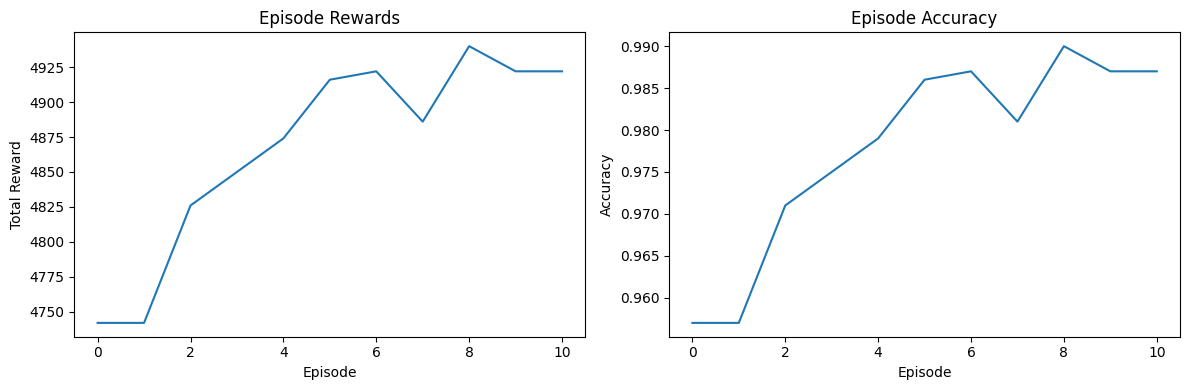

In [14]:
# 3. Policy Network RL training
env = MNISTEnvironment(x_test[:1000], y_test[:1000])  # Reduce samples
policy = PolicyNetwork(base_model)
policy.buffer_size = 64  # Increase batch size

episodes = 150  # Increase from 100 to 150
rewards_history = []
accuracy_history = []
best_accuracy = 0
patience = 7  # Adjust patience to 7
patience_counter = 0

progress_bar = tqdm(range(episodes), desc="Training RL")

# Training loop
for episode in progress_bar:
    state = env.reset()
    done = False
    episode_loss = 0
    correct_predictions = 0
    total_predictions = 0

    while not done:
        action, _ = policy.get_action(state, training=True)
        next_state, reward, done, true_label = env.step(action)
        
        # Store experience
        policy.state_buffer.append(state)
        policy.action_buffer.append(action)
        policy.reward_buffer.append(reward)
        
        # In the training loop, when updating
        if len(policy.state_buffer) >= policy.buffer_size:
            states = np.array(policy.state_buffer, dtype=np.float32)
            actions = np.array(policy.action_buffer, dtype=np.int32)
            rewards = np.array(policy.reward_buffer, dtype=np.float32)
            
            loss = policy.train_step(states, actions, rewards)
            episode_loss += loss
            
            # Clear buffers
            policy.state_buffer = []
            policy.action_buffer = []
            policy.reward_buffer = []
        
        if action == true_label:
            correct_predictions += 1
        total_predictions += 1
        
        if not done:
            state = next_state
    
    episode_accuracy = correct_predictions / total_predictions
    rewards_history.append(env.episode_reward)
    accuracy_history.append(episode_accuracy)
    
    # Early stopping
    patience = 5  # Reduce from 10 to 5
    min_delta = 0.01  # Add minimum improvement threshold

    # In the training loop
    if episode_accuracy > best_accuracy + min_delta:
        best_accuracy = episode_accuracy
        patience_counter = 0
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"\nEarly stopping at episode {episode}")
        break
    
    progress_bar.set_postfix({
        'reward': f'{env.episode_reward:.2f}',
        'acc': f'{episode_accuracy:.2%}',
        'loss': f'{float(episode_loss):.2f}'
    })

# Add learning rate decay for policy network
policy.optimizer.learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=50,
    decay_rate=0.96
)

# Plot training results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(rewards_history)
plt.title('Episode Rewards')
plt.xlabel('Episode')
plt.ylabel('Total Reward')

plt.subplot(1, 2, 2)
plt.plot(accuracy_history)
plt.title('Episode Accuracy')
plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


In [15]:
# Final evaluation
correct = 0
total = 0
for x, y in zip(x_test, y_test):
    action, _ = policy.get_action(x)
    if action == y:
        correct += 1
    total += 1

print(f"Final Test Accuracy: {correct/total:.2%}")

Final Test Accuracy: 97.11%


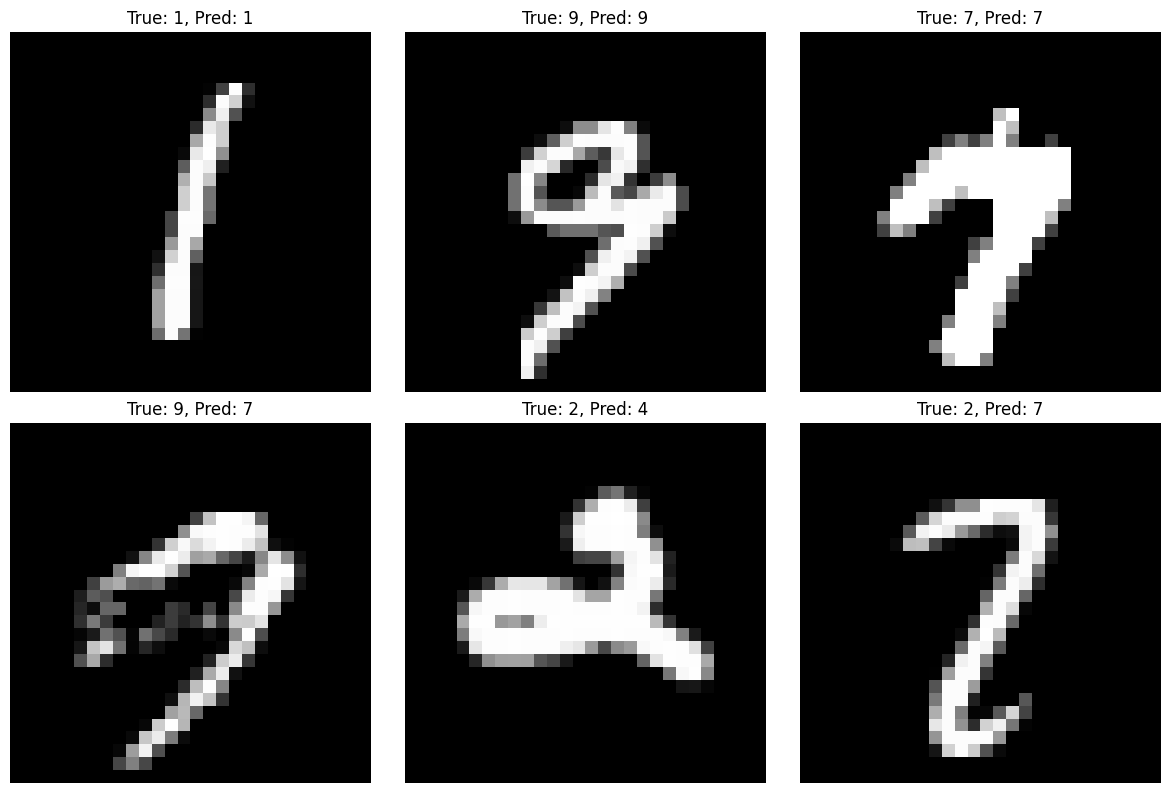

In [16]:
# Error analysis: Display 3 correct and 3 incorrect predictions
import random

# Collect correct and incorrect predictions
correct_predictions = []
incorrect_predictions = []

for x, y in zip(x_test, y_test):
    action, _ = policy.get_action(x)
    if action == y:
        correct_predictions.append((x, y, action))
    else:
        incorrect_predictions.append((x, y, action))

# Randomly select 3 correct and 3 incorrect predictions
correct_samples = random.sample(correct_predictions, 3)
incorrect_samples = random.sample(incorrect_predictions, 3)

# Plot the results
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Display correct predictions on the top row
for i, (img, true_label, pred_label) in enumerate(correct_samples):
    axes[0, i].imshow(img.squeeze(), cmap='gray')
    axes[0, i].set_title(f"True: {true_label}, Pred: {pred_label}")
    axes[0, i].axis('off')

# Display incorrect predictions on the bottom row
for i, (img, true_label, pred_label) in enumerate(incorrect_samples):
    axes[1, i].imshow(img.squeeze(), cmap='gray')
    axes[1, i].set_title(f"True: {true_label}, Pred: {pred_label}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()